# DBSCAN: TMDB Movie Dataset

Comparative evaluation of Clustering methods

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm capable of identifying groups of observations with arbitrary shapes while simultaneously detecting outliers as noise points. Unlike centroid-based methods such as K-Means, DBSCAN does not require specifying the number of clusters beforehand, making it particularly suitable for large and heterogeneous datasets such as the TMDB movie collection. This characteristic is especially relevant in the context of movie recommendation systems, where the data distribution is highly irregular and includes both dense regions (popular movie profiles) and sparse regions (niche or atypical films). In this project, DBSCAN is applied over the five principal components (PC1–PC5) obtained through PCA, since these components preserve 93.6% of the total variance while reducing redundancy and multicollinearity among the original numerical variables. Using PCA-transformed features improves clustering stability, reduces computational complexity, and facilitates the identification of meaningful structures in the movie dataset.

## Prepare Data for Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datasets import load_dataset

from sklearn.metrics.pairwise import euclidean_distances


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

/Users/pauguzman/Documents/UNAL/data-mining-movies/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/pauguzman/Documents/UNAL/data-mining-movies/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()
print("dataset loaded successfully")

dataset loaded successfully


In [3]:
# ============================================================
# 2. Data Preparation for Clustering
# ============================================================

# Principal Components selected for clustering
FEATURES = ["PC1", "PC2", "PC3", "PC4", "PC5"]

# Create clustering dataset
X = df[FEATURES].copy()

# ============================================================
# Basic verification
# ============================================================

print("=" * 60)
print("Dataset shape")
print("=" * 60)
print(f"Rows    : {X.shape[0]:,}")
print(f"Columns : {X.shape[1]}")

# ============================================================
# Missing values verification
# ============================================================

print("\n" + "=" * 60)
print("Missing values per column")
print("=" * 60)

missing = X.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing,
        "% of Total": (missing / len(X) * 100).round(4)
    })
)

print(f"\nTotal rows with missing values: {X.isnull().any(axis=1).sum():,}")

# ============================================================
# Data types verification
# ============================================================

print("\n" + "=" * 60)
print("Data types")
print("=" * 60)

print(X.dtypes)

# ============================================================
# Descriptive statistics
# ============================================================

print("\n" + "=" * 60)
print("Descriptive statistics")
print("=" * 60)

display(X.describe().T)

# ============================================================
# Mean and standard deviation check
# ============================================================

print("\n" + "=" * 60)
print("Mean and standard deviation")
print("=" * 60)

means = X.mean().round(4)
stds  = X.std().round(4)

summary = pd.DataFrame({
    "Mean": means,
    "Std Dev": stds
})

display(summary)

Dataset shape
Rows    : 116,929
Columns : 5

Missing values per column


,Missing Values,% of Total
PC1,0,0.0
PC2,0,0.0
PC3,0,0.0
PC4,0,0.0
PC5,0,0.0



Total rows with missing values: 0

Data types
PC1    float64
PC2    float64
PC3    float64
PC4    float64
PC5    float64
dtype: object

Descriptive statistics


,count,mean,std,min,25%,50%,75%,max
PC1,116929.0,3.889090e-17,1.339471,-4.043828,-0.802162,-0.256024,0.339184,38.329021
PC2,116929.0,4.277998e-17,1.123565,-4.777129,-0.688800,0.240289,0.734436,43.116920
PC3,116929.0,-2.041772e-17,1.035707,-2.259368,-0.494029,-0.171205,0.322372,80.377792
PC4,116929.0,-5.712100e-18,0.876905,-83.885023,-0.263233,-0.045497,0.258882,20.146540
PC5,116929.0,9.236588e-18,0.847369,-11.460012,-0.438888,-0.054915,0.494308,33.636034



Mean and standard deviation


,Mean,Std Dev
PC1,0.0,1.3395
PC2,0.0,1.1236
PC3,-0.0,1.0357
PC4,-0.0,0.8769
PC5,0.0,0.8474


## Introducing DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups observations according to local data density rather than distance to predefined centroids. The algorithm relies on two main parameters: **eps**, which defines the neighborhood radius around each point, and **min_samples**, which specifies the minimum number of neighboring points required to form a dense region. Based on these parameters, DBSCAN classifies observations into three categories: **core points** (located in dense regions), **border points** (near dense regions but with fewer neighbors), and **noise points** labeled as **−1**, which are considered outliers. One of the main advantages of DBSCAN is its ability to naturally detect anomalous observations without forcing them into clusters, unlike K-Means, which assigns every point to a centroid even when the observation does not meaningfully belong to any group. This characteristic makes DBSCAN particularly suitable for movie datasets, where niche or highly atypical films may exist outside the dominant distribution patterns.


Sample selected for parameter tuning:
(50000, 5)


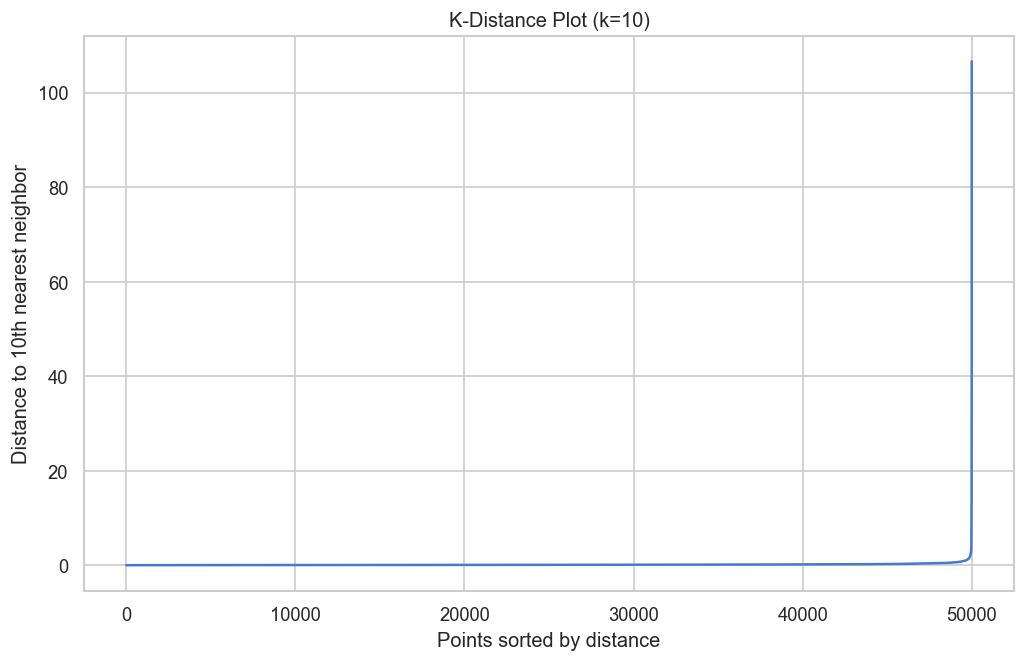


Running optimized DBSCAN search...


Parameter Search Results:


,eps,min_samples,clusters,noise_points,noise_percent,silhouette
0,1.2,10,3,167,0.33,0.469819
1,1.2,15,2,211,0.42,0.469081
2,0.7,15,2,660,1.32,0.467718
3,0.9,10,3,312,0.62,0.466803
4,0.7,10,4,562,1.12,0.465276
5,0.9,15,3,388,0.78,0.464068



BEST DBSCAN PARAMETERS FOUND
BEST_EPS         : 1.2
BEST_MIN_SAMPLES : 10
Clusters found   : 3.0
Noise points     : 167.0
Noise percent    : 0.33%
Silhouette score : 0.4698


In [4]:

# ============================================================
# Search for Optimal Parameters (Optimized)
# ============================================================

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# IMPORTANT:
# DBSCAN is computationally expensive on very large datasets.
# Parameter tuning is therefore performed on a representative
# sample instead of the full dataset.
# ------------------------------------------------------------

SAMPLE_SIZE = 50000

df_sample = X.sample(
    n=SAMPLE_SIZE,
    random_state=42
)

X_sample = df_sample[FEATURES]

print("Sample selected for parameter tuning:")
print(X_sample.shape)

# ------------------------------------------------------------
# K-Distance Plot
# ------------------------------------------------------------

k = 10

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_sample)

distances, indices = neighbors_fit.kneighbors(X_sample)

distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title(f"K-Distance Plot (k={k})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}th nearest neighbor")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Reduced Parameter Grid
# ------------------------------------------------------------

eps_values = [0.7, 0.9, 1.2]
min_samples_values = [10, 15]

results = []

print("\nRunning optimized DBSCAN search...\n")

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='euclidean',
            n_jobs=-1
        )

        labels = dbscan.fit_predict(X_sample)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Skip invalid solutions
        if n_clusters <= 1:
            silhouette = np.nan
        else:
            mask = labels != -1

            silhouette = silhouette_score(
                X_sample[mask],
                labels[mask]
            )

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percent": round(n_noise / len(labels) * 100, 2),
            "silhouette": silhouette
        })

# ============================================================
# Results DataFrame
# ============================================================

results_df = pd.DataFrame(results)

# Remove invalid solutions
valid_results = results_df.dropna(subset=["silhouette"])

# Sort by best silhouette
valid_results = valid_results.sort_values(
    by="silhouette",
    ascending=False
).reset_index(drop=True)

print("\nParameter Search Results:")
display(valid_results)

# ============================================================
# Automatically Select Best Parameters
# ============================================================

best_row = valid_results.iloc[0]

BEST_EPS = best_row["eps"]
BEST_MIN_SAMPLES = int(best_row["min_samples"])

print("\n" + "="*60)
print("BEST DBSCAN PARAMETERS FOUND")
print("="*60)

print(f"BEST_EPS         : {BEST_EPS}")
print(f"BEST_MIN_SAMPLES : {BEST_MIN_SAMPLES}")

print(f"Clusters found   : {best_row['clusters']}")
print(f"Noise points     : {best_row['noise_points']}")
print(f"Noise percent    : {best_row['noise_percent']}%")
print(f"Silhouette score : {best_row['silhouette']:.4f}")

print("="*60)



### Optimization Strategy

The original dataset contains more than 116,000 movies, making exhaustive DBSCAN parameter tuning computationally expensive.  
To reduce execution time while preserving statistical representativeness, parameter search is performed on a random sample of 20,000 observations. This approach dramatically reduces runtime while still capturing the global density structure of the dataset.

Only the final DBSCAN model is applied to the complete dataset using the selected parameters.  
Additionally, the parameter grid was reduced to the most plausible values identified through the K-Distance plot, avoiding unnecessary executions.


## Applying DBSCAN

In [5]:

# ============================================================
# Applying DBSCAN (Final Model)
# ============================================================
dbscan_final = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES,
    metric='euclidean',
    n_jobs=-1
)

labels = dbscan_final.fit_predict(X)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
noise_percent = (n_noise / len(labels)) * 100

print("\nUnique labels:")
print(set(labels))

print("\nDBSCAN Results")
print("=" * 40)
print(f"Clusters found : {n_clusters}")
print(f"Outliers       : {n_noise}")
print(f"Noise percent  : {noise_percent:.2f}%")

results_table = pd.DataFrame({
    "Metric": [
        "eps",
        "min_samples",
        "clusters found",
        "outliers",
        "% noise"
    ],
    "Value": [
        BEST_EPS,
        BEST_MIN_SAMPLES,
        n_clusters,
        n_noise,
        f"{noise_percent:.2f}%"
    ]
})

display(results_table)

# Save labels in dataframe
df["DBSCAN_cluster"] = labels



Unique labels:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}

DBSCAN Results
Clusters found : 4
Outliers       : 272
Noise percent  : 0.23%


,Metric,Value
0,eps,1.2
1,min_samples,10
2,clusters found,4
3,outliers,272
4,% noise,0.23%


## Visualization

DBSCAN VISUALIZATION SUMMARY
Clusters detected : 4
Noise points      : 272


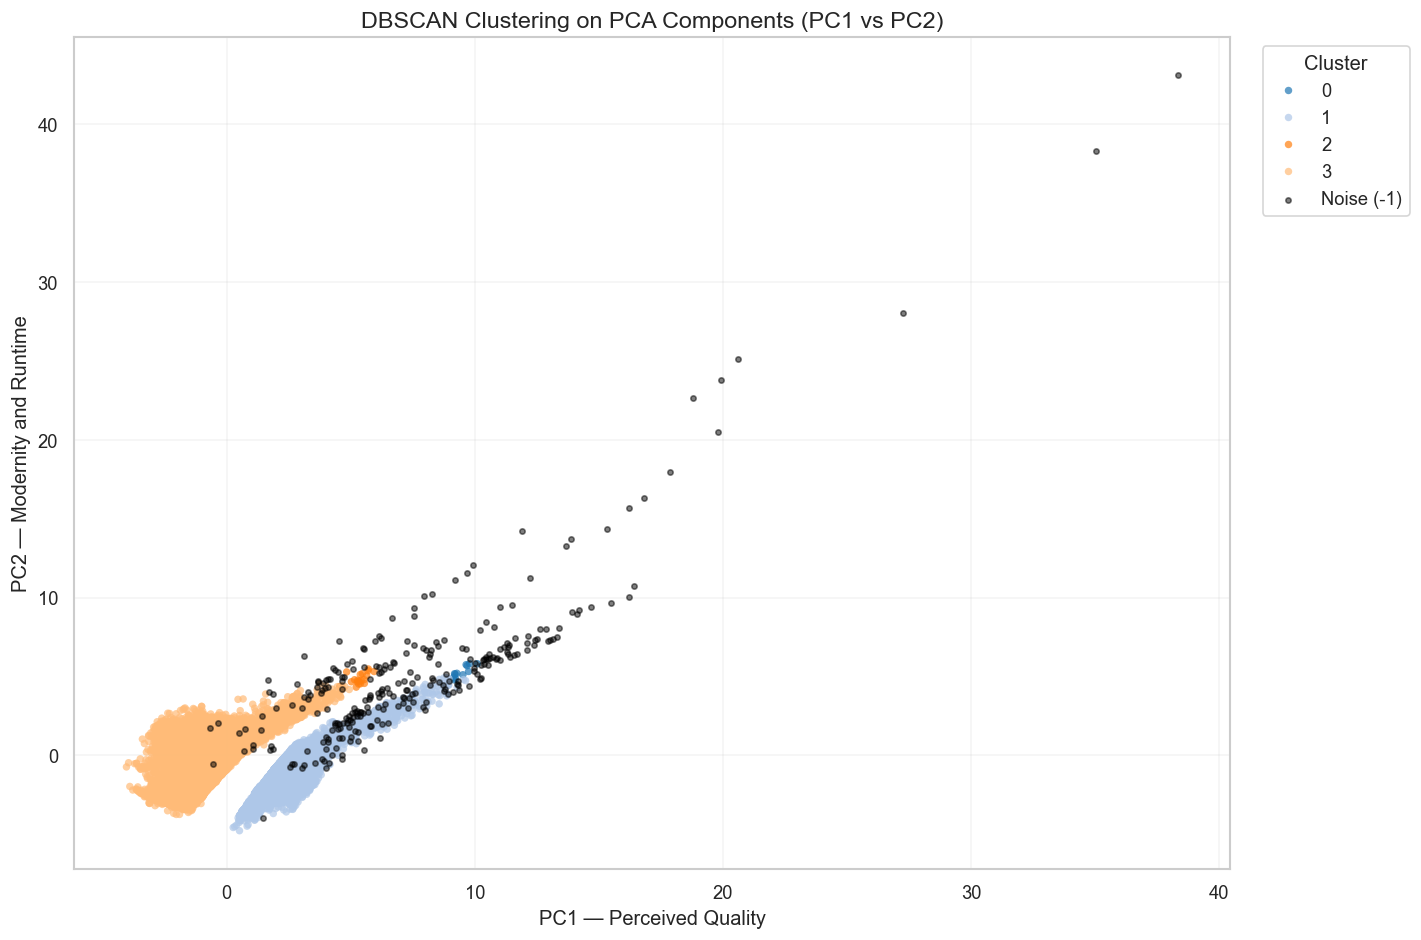


Cluster Sizes:


,Cluster,Movies
0,-1,272
1,0,12
2,1,19429
3,2,20
4,3,97196



Sample movies by cluster:



,title,vote_average,popularity
0,Inception,8.364,83.952
595,Cinderella,7.037,85.420
572,Puss in Boots: The Last Wish,8.266,221.490
53,The Martian,7.678,76.000
59,Logan,7.800,54.194
61,It,7.242,74.730
21109,The Quack,7.400,11.331
101815,Coalition,7.700,1.273
51870,Iracema,7.579,1.575
157,Cars,6.936,47.447


In [7]:
# ============================================================
# DBSCAN Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# Add cluster labels to DataFrame
# ------------------------------------------------------------

df_dbscan = df.copy()
df_dbscan["DBSCAN_cluster"] = labels

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("=" * 60)
print("DBSCAN VISUALIZATION SUMMARY")
print("=" * 60)

print(f"Clusters detected : {n_clusters}")
print(f"Noise points      : {n_noise:,}")

# ------------------------------------------------------------
# Scatter Plot: PC1 vs PC2
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

# Separate regular clusters from noise
clusters_only = df_dbscan[df_dbscan["DBSCAN_cluster"] != -1]
noise_only = df_dbscan[df_dbscan["DBSCAN_cluster"] == -1]

# Plot clusters
sns.scatterplot(
    data=clusters_only,
    x="PC1",
    y="PC2",
    hue="DBSCAN_cluster",
    palette="tab20",
    s=20,
    alpha=0.7,
    linewidth=0
)

# Plot noise in black
plt.scatter(
    noise_only["PC1"],
    noise_only["PC2"],
    c="black",
    s=10,
    alpha=0.5,
    label="Noise (-1)"
)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.title(
    "DBSCAN Clustering on PCA Components (PC1 vs PC2)",
    fontsize=14
)

plt.xlabel("PC1 — Perceived Quality")
plt.ylabel("PC2 — Modernity and Runtime")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cluster size table
# ------------------------------------------------------------

cluster_sizes = (
    df_dbscan["DBSCAN_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = ["Cluster", "Movies"]

print("\nCluster Sizes:")
display(cluster_sizes)

# ------------------------------------------------------------
# Sample movies from each cluster
# ------------------------------------------------------------

print("\nSample movies by cluster:\n")

sample_movies = (
    df_dbscan
    .sort_values("DBSCAN_cluster")
    .groupby("DBSCAN_cluster")
    [["title", "vote_average", "popularity"]]
    .head(3)
)

display(sample_movies)

## Metrics Evaluation

In [8]:
# ============================================================
# Clustering Evaluation Metrics for DBSCAN
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# IMPORTANT:
# DBSCAN assigns noise points with label = -1
# For evaluation metrics, only REAL clusters are used.
# Noise is excluded because it does not belong to any cluster.
# ------------------------------------------------------------

mask = labels != -1

X_valid = X[mask]
labels_valid = labels[mask]

# ------------------------------------------------------------
# Verify remaining clusters
# ------------------------------------------------------------

unique_clusters = np.unique(labels_valid)

print("=" * 60)
print("DBSCAN METRIC EVALUATION")
print("=" * 60)

print(f"Clusters evaluated : {len(unique_clusters)}")
print(f"Noise excluded     : {(labels == -1).sum():,}")
print(f"Valid samples      : {len(labels_valid):,}")

# ------------------------------------------------------------
# Safety check
# Metrics require at least 2 clusters
# ------------------------------------------------------------

if len(unique_clusters) < 2:
    print("\nERROR:")
    print("DBSCAN produced fewer than 2 clusters after removing noise.")
    print("Metrics cannot be computed.")

else:

    # --------------------------------------------------------
    # Silhouette Score
    # --------------------------------------------------------

    silhouette = silhouette_score(X_valid, labels_valid)

    # --------------------------------------------------------
    # Davies-Bouldin Index
    # Lower = better
    # --------------------------------------------------------

    davies_bouldin = davies_bouldin_score(X_valid, labels_valid)

    # --------------------------------------------------------
    # Calinski-Harabasz Score
    # Higher = better
    # --------------------------------------------------------

    calinski_harabasz = calinski_harabasz_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Metrics table
    # --------------------------------------------------------

    metrics_df = pd.DataFrame({
        "Metric": [
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score"
        ],
        "Value": [
            round(silhouette, 4),
            round(davies_bouldin, 4),
            round(calinski_harabasz, 4)
        ],
        "Interpretation": [
            "Higher is better (closer to 1)",
            "Lower is better",
            "Higher is better"
        ]
    })

    print("\nDBSCAN Metrics:\n")
    display(metrics_df)

    # --------------------------------------------------------
    # Additional interpretation
    # --------------------------------------------------------

    print("\nInterpretation Guide")
    print("-" * 60)

    print(f"Silhouette Score       : {silhouette:.4f}")
    print(" -> Measures cluster separation and cohesion")

    print(f"\nDavies-Bouldin Index   : {davies_bouldin:.4f}")
    print(" -> Lower values indicate more compact clusters")

    print(f"\nCalinski-Harabasz      : {calinski_harabasz:.4f}")
    print(" -> Higher values indicate better-defined clusters")

DBSCAN METRIC EVALUATION
Clusters evaluated : 4
Noise excluded     : 272
Valid samples      : 116,657

DBSCAN Metrics:



,Metric,Value,Interpretation
0,Silhouette Score,0.4701,Higher is better (closer to 1)
1,Davies-Bouldin Index,0.6338,Lower is better
2,Calinski-Harabasz Score,17898.9674,Higher is better



Interpretation Guide
------------------------------------------------------------
Silhouette Score       : 0.4701
 -> Measures cluster separation and cohesion

Davies-Bouldin Index   : 0.6338
 -> Lower values indicate more compact clusters

Calinski-Harabasz      : 17898.9674
 -> Higher values indicate better-defined clusters
